<h1 style="color:#2ca02c;">КРОК 1.1: Сервісні Підключення</h1>
Підключення бібліотек, вказуємо шлях до файлу, створюємо датафрейм

In [1]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import openpyxl
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.exceptions import ConvergenceWarning
from scipy.optimize import minimize
import warnings

root_path = '/Users/radyslav/data_analysis/Amazon/prod_perc_dpack/B-Complex Capsules'
# функція для сканування базової папки

dataframes_list = []

<h1 style="color:#2ca02c;">КРОК 1.2: Сервісний Скріпт: Динамічне Вилучення Фінансових Витрат за ASIN</h1>

Ця функція зчитує файл `Product Cost Info.xlsx` та динамічно вибирає **ASIN** і пов'язані з ним витрати (COGS, FBA Fee, Ref Fee) для `Double Pack`. Ми орієнтуємося на назву продукту та припускаємо, що Double Pack має найбільший об'єм у своїй групі. Це забезпечує масштабованість.

In [2]:
# УВАГА: Припускаємо, що root_path та основна назва продукту вже визначені.
product_folder_name = os.path.basename(root_path)
cost_file_path = os.path.join(os.path.dirname(root_path), 'Product Cost Info.xlsx')


def get_product_costs_by_asin(cost_file_path, product_folder_name):
    """
    Динамічно зчитує файл собівартості, використовуючи ASIN для Double Pack,
    з автоматичним виправленням формату Ref Fee.
    """
    try:
        # ПРИПУСКАЄМО, що файл стандартизовано і шапка знаходиться у рядку 1 (header=0)
        df_costs = pd.read_excel(cost_file_path, header=0)
    except FileNotFoundError:
        print(f"Помилка: Файл собівартості не знайдено за шляхом: {cost_file_path}")
        return None

    # 1. Очищення назв стовпців для безпечного доступу
    df_costs.columns = df_costs.columns.str.strip().str.replace(' ', '_')
    df_costs = df_costs.dropna(subset=['Short_Product_Name']).reset_index(drop=True)

    # 2. Очищення назви продукту для пошуку
    base_product_name = product_folder_name.replace(' Capsules', '').strip()

    # 3. Фільтруємо дані
    df_product_group = df_costs[df_costs['Short_Product_Name'].str.contains(base_product_name, case=False, na=False)].copy()

    if df_product_group.empty:
        print(f"Помилка: Не знайдено даних про витрати для продукту: {base_product_name}")
        return None

    # 4. Визначення Double Pack
    df_product_group['Capsule_Count'] = df_product_group['Short_Product_Name'].str.extract(r'(\d+)').astype(int)
    dp_data = df_product_group.loc[df_product_group['Capsule_Count'].idxmax()]

    # 5. КЛЮЧОВЕ ВИПРАВЛЕННЯ: Автоматичне перетворення Ref_Fee
    ref_fee_raw = dp_data['Ref_Fee']
    
    if isinstance(ref_fee_raw, str):
        # Якщо це рядок ('15%'), видаляємо '%' і перетворюємо на десятковий дріб (ділимо на 100)
        ref_fee_rate = float(ref_fee_raw.strip().replace('%', '').replace(',', '.')) / 100
    elif isinstance(ref_fee_raw, (int, float)):
        # Якщо це число. Якщо 15, ділимо на 100. Якщо 0.15, залишаємо.
        # Використовуємо простий поріг, щоб перевірити, чи це вже дріб
        ref_fee_rate = ref_fee_raw / 100 if ref_fee_raw > 1 else ref_fee_raw
    else:
        # Усі інші випадки, встановлюємо 0 і попереджаємо
        ref_fee_rate = 0.0
        print("Попередження: Ref Fee має невідомий формат. Встановлено 0%.")

    # 6. Зберігаємо ключові змінні
    costs = {
        'asin_dp': dp_data['ASIN'],
        'cogs_dp': dp_data['COGS'],
        'fba_dp': dp_data['FBA_Fee'],
        'ref_fee_rate': ref_fee_rate
    }
    return costs

# Запуск функції та збереження фінансових даних
financial_costs = get_product_costs_by_asin(cost_file_path, product_folder_name)

if financial_costs:
    # Зберігаємо змінні у глобальну пам'ять
    asin_dp = financial_costs['asin_dp']
    cogs_dp = financial_costs['cogs_dp']
    fba_dp = financial_costs['fba_dp']
    ref_fee_rate = financial_costs['ref_fee_rate']
    
    print(f"Дані для Double Pack ({product_folder_name}) успішно витягнуто:")
    print(f"  ASIN Double Pack: {asin_dp}")
    print(f"  COGS: ${cogs_dp:.2f}")
    print(f"  FBA Fee: ${fba_dp:.2f}")
    print(f"  Ref Fee Rate: {ref_fee_rate*100:.0f}%")
else:
    print("Не вдалося витягнути фінансові дані. Перевірте шлях до файлу та назви продукту.")

Дані для Double Pack (B-Complex Capsules) успішно витягнуто:
  ASIN Double Pack: B0DGQVJDXV
  COGS: $5.34
  FBA Fee: $3.90
  Ref Fee Rate: 15%


<h1 style="color:#2ca02c;">КРОК 1.3: Інжинірінг Даних</h1>
Дані розрізнені та представлені в окремих файлах.

**Алгоритм обробки**
* Обєднання всіх файлів в один датафрейм, як по сінглпакам, так і по даблпакам
* Привязка даних до конкретних місяців, для цього застосована агрегація і назви файлів
* Дані в сирому виді були в незручному форматі, за допомогою реджексів очистили дані
* Відсортували дані по місяцям
* Виконали фільтр і залишили лише ті міясці, в яких одочасно присутні дані як по сінглпакам, так і по даблпакам
* Створено колонки, в яких одразу провели сумування по B2C та B2B сегментам та занесли дані в окремі показники

In [3]:
for dirpath, dirnames, filenames in os.walk(root_path):
    for file_name in filenames:
        if file_name.endswith('.csv'):
            file_path = os.path.join(dirpath, file_name)
            
            try:
                df = pd.read_csv(file_path)
            except Exception as e:
                print(f"Помилка при читанні файлу {file_name}: {e}")
                continue

            # Обробка даних: видалення символів та перетворення на числа.
            for col in ['Units Ordered', 'Units Ordered - B2B',
                        'Ordered Product Sales', 'Ordered Product Sales - B2B',
                        'Sessions - Total', 'Sessions - Total - B2B']:
                if col in df.columns:
                    df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
            
            pack_type_folder_name = os.path.basename(dirpath)
            pack_type_match = re.search(r'(Single Pack|Double Pack)', pack_type_folder_name)
            df['pack_type'] = pack_type_match.group(0) if pack_type_match else 'Невідомий'
            
            month_year_match = re.search(r'(January|February|March|April|May|June|July|August|September|October|November|December)_(20\d{2})', file_name)
            if month_year_match:
                date_str = f"{month_year_match.group(2)}-{month_year_match.group(1)}-01"
                df['date'] = pd.to_datetime(date_str)
            else:
                df['date'] = pd.NaT
            
            # Перейменовуємо колонки сесій для зручності
            df = df.rename(columns={'Sessions - Total': 'Sessions', 'Sessions - Total - B2B': 'Sessions - B2B'})
            
            df = df[[
                'pack_type', 'date', 'Units Ordered', 'Units Ordered - B2B',
                'Ordered Product Sales', 'Ordered Product Sales - B2B',
                'Sessions', 'Sessions - B2B'
            ]]
            
            dataframes_list.append(df)

all_data = pd.concat(dataframes_list, ignore_index=True)

# Агрегуємо дані по даті та типу пакування
aggregated_data = all_data.groupby(['date', 'pack_type']).sum(numeric_only=True).reset_index()

# Фільтруємо місяці, в яких присутні дані для обох пакувань
months_with_both_packs = aggregated_data.groupby('date')['pack_type'].nunique()
complete_months = months_with_both_packs[months_with_both_packs == 2].index

filtered_data = aggregated_data[aggregated_data['date'].isin(complete_months)].copy()

# Створюємо нові колонки із загальними показниками
filtered_data['Total Units Ordered'] = filtered_data['Units Ordered'] + filtered_data['Units Ordered - B2B']
filtered_data['Total Ordered Product Sales'] = filtered_data['Ordered Product Sales'] + filtered_data['Ordered Product Sales - B2B']
filtered_data['Total Sessions'] = filtered_data['Sessions'] + filtered_data['Sessions - B2B']

# Візуальне виведення для перевірки
print("Агрегований та відфільтрований датафрейм:")
filtered_data

Агрегований та відфільтрований датафрейм:


,date,pack_type,Units Ordered,Units Ordered - B2B,Ordered Product Sales,Ordered Product Sales - B2B,Sessions,Sessions - B2B,Total Units Ordered,Total Ordered Product Sales,Total Sessions
1,2024-12-01,Double Pack,753.0,7.0,18311.19,169.84,2474.0,63.0,760.0,18481.03,2537.0
2,2024-12-01,Single Pack,4397.0,71.0,85502.72,1208.26,34152.0,575.0,4468.0,86710.98,34727.0
3,2025-01-01,Double Pack,1195.0,22.0,36154.77,624.80,3673.0,89.0,1217.0,36779.57,3762.0
4,2025-01-01,Single Pack,5016.0,78.0,99335.36,1333.15,28993.0,458.0,5094.0,100668.51,29451.0
5,2025-02-01,Double Pack,580.0,6.0,18857.29,184.09,1751.0,30.0,586.0,19041.38,1781.0
6,2025-02-01,Single Pack,7023.0,116.0,132444.97,1972.38,34317.0,609.0,7139.0,134417.35,34926.0
7,2025-03-01,Double Pack,1231.0,29.0,42723.94,903.64,3912.0,103.0,1260.0,43627.58,4015.0
8,2025-03-01,Single Pack,8026.0,121.0,152040.91,2080.79,37059.0,634.0,8147.0,154121.70,37693.0
9,2025-04-01,Double Pack,1254.0,22.0,43370.75,691.05,4104.0,85.0,1276.0,44061.80,4189.0
10,2025-04-01,Single Pack,7631.0,104.0,143406.46,1775.54,34842.0,592.0,7735.0,145182.00,35434.0


<h1 style="color:#2ca02c;">КРОК 1.4: Виділення Даних у Зведений Датасет (pivot)</h1>
**Алгоритм зведення**
* Виділяємо значущі колонки у вигляді списку
* Через мельт впорядковуємо дані по місяцям і одразу фільтруємо по сінглпаку та даблпаку
* Створюємо зведену таблицю та наповнємо її виділеними параметрами

In [4]:
# Визначаємо показники, які будуть в рядках таблиці
metrics = [
    'Total Units Ordered',
    'Total Ordered Product Sales',
    'Total Sessions'
]

# Крок 1: "Розтоплюємо" відфільтрований датафрейм
melted_data = filtered_data.melt(
    id_vars=['date', 'pack_type'],
    value_vars=metrics,
    var_name='Metric',
    value_name='Value'
)

# Крок 2: Створюємо зведену таблицю
pivoted_data = melted_data.pivot_table(
    index='Metric',
    columns=['date', 'pack_type'],
    values='Value',
    fill_value=0
)

# Крок 3: Сортуємо колонки для правильного хронологічного порядку
pivoted_data = pivoted_data.sort_index(axis=1, level='date')

# Крок 4: Сортуємо паки так, щоб Single Pack йшов першим
sorted_pack_types = ['Single Pack', 'Double Pack']
sorted_dates = pivoted_data.columns.get_level_values('date').unique()

new_order = pd.MultiIndex.from_product([sorted_dates, sorted_pack_types], names=['date', 'pack_type'])

pivoted_data = pivoted_data.reindex(columns=new_order)

print("Остаточна зведена таблиця:")
pivoted_data

Остаточна зведена таблиця:


date                         2024-12-01              2025-01-01              \
pack_type                   Single Pack Double Pack Single Pack Double Pack   
Metric                                                                        
Total Ordered Product Sales    86710.98    18481.03   100668.51    36779.57   
Total Sessions                 34727.00     2537.00    29451.00     3762.00   
Total Units Ordered             4468.00      760.00     5094.00     1217.00   

date                         2025-02-01              2025-03-01              \
pack_type                   Single Pack Double Pack Single Pack Double Pack   
Metric                                                                        
Total Ordered Product Sales   134417.35    19041.38    154121.7    43627.58   
Total Sessions                 34926.00     1781.00     37693.0     4015.00   
Total Units Ordered             7139.00      586.00      8147.0     1260.00   

date                         2025-04-01              2025-05-01              \
pack_type                   Single Pack Double Pack Single Pack Double Pack   
Metric                                                                        
Total Ordered Product Sales    145182.0     44061.8   152067.03     52474.8   
Total Sessions                  35434.0      4189.0    38376.00      4516.0   
Total Units Ordered              7735.0      1276.0     8060.00      1597.0   

date                         2025-06-01              2025-07-01              \
pack_type                   Single Pack Double Pack Single Pack Double Pack   
Metric                                                                        
Total Ordered Product Sales   153200.16     61490.8   249397.06    67793.02   
Total Sessions                 63594.00      7220.0   108390.00    11635.00   
Total Units Ordered             7718.00      1934.0    13002.00     2014.00   

date                         2025-08-01              
pack_type                   Single Pack Double Pack  
Metric                                               
Total Ordered Product Sales   284082.78   106447.52  
Total Sessions                128509.00    12977.00  
Total Units Ordered            15471.00     3448.00

<h1 style="color:#2ca02c;">КРОК 2.1: Розрахунок Середньозваженої Ціни</h1>
Для Single Pack та Double Pack розраховуємо середньозважену ціну по місяцям. Для цього Total Ordered Product Sales / Total Units Ordered

In [5]:
# Вибираємо рядки із загальною виручкою та загальною кількістю одиниць
sales_data = pivoted_data.loc['Total Ordered Product Sales']
units_data = pivoted_data.loc['Total Units Ordered']

# Розраховуємо середню ціну за одиницю, ділячи виручку на кількість одиниць
average_price = sales_data / units_data

# Округлюємо результат до двох знаків після коми
# Цей рядок додає функціонал округлення
average_price = average_price.round(2)

# Створюємо новий датафрейм для результатів
average_price_df = average_price.to_frame(name='Average Price').T

# Виводимо нову таблицю
print("Середньозважена ціна за одиницю:")
average_price_df

Середньозважена ціна за одиницю:


date           2024-12-01              2025-01-01              2025-02-01  \
pack_type     Single Pack Double Pack Single Pack Double Pack Single Pack   
Average Price       19.41       24.32       19.76       30.22       18.83   

date                       2025-03-01              2025-04-01              \
pack_type     Double Pack Single Pack Double Pack Single Pack Double Pack   
Average Price       32.49       18.92       34.63       18.77       34.53   

date           2025-05-01              2025-06-01              2025-07-01  \
pack_type     Single Pack Double Pack Single Pack Double Pack Single Pack   
Average Price       18.87       32.86       19.85       31.79       19.18   

date                       2025-08-01              
pack_type     Double Pack Single Pack Double Pack  
Average Price       33.66       18.36       30.87

<h1 style="color:#2ca02c;">КРОК 2.2: Розрахунок Фактичої Знижки на Double Pack</h1>
Для цього discount_percentage = ((1 - (double_pack_price / (single_pack_price * 2))) * 100)

In [6]:
# Вибираємо рядки із загальною виручкою та загальною кількістю одиниць з pivoted_data
sales_data = pivoted_data.loc['Total Ordered Product Sales']
units_data = pivoted_data.loc['Total Units Ordered']

# Крок 1: Розраховуємо середню ціну за одиницю, ділячи виручку на кількість одиниць
average_price = sales_data / units_data

# Крок 2: Отримуємо середню ціну для Single Pack та Double Pack
single_pack_price = average_price.xs('Single Pack', level='pack_type')
double_pack_price = average_price.xs('Double Pack', level='pack_type')

# Крок 3: Розраховуємо відсоток знижки
discount_percentage = ((1 - (double_pack_price / (single_pack_price * 2))) * 100).round(2)

# Крок 4: Створюємо новий датафрейм з правильною структурою колонок
# Створюємо MultiIndex, що містить тільки дати і підпис "Double Pack"
# pd.MultiIndex.from_product() створює всі можливі комбінації
columns_index = pd.MultiIndex.from_product(
    [discount_percentage.index, ['Double Pack']],
    names=['date', 'pack_type']
)

# Створюємо новий датафрейм із розрахованими значеннями
discount_percentage_df = pd.DataFrame(
    [discount_percentage.values],
    index=['Discount Percentage'],
    columns=columns_index
)

# Крок 5: Форматуємо значення, додаючи знак відсотка
# Використовуємо нову функцію .map(), щоб застосувати форматування до кожного елемента
discount_percentage_df = discount_percentage_df.map(lambda x: f"{x:.2f}%")

print("Відсоток знижки для Double Pack по місяцях:")
discount_percentage_df

Відсоток знижки для Double Pack по місяцях:


date,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01
pack_type,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack
Discount Percentage,37.35%,23.54%,13.71%,8.48%,8.01%,12.92%,19.91%,12.26%,15.94%


<h1 style="color:#2ca02c;">КРОК 2.3: Розрахунок Конверсії Апсейлу</h1>
Продаж даблпаку залежить не від продажів сінглпаку, а від трафіку, який приходить на сторінку товару.

Прості продажі (Total Units Ordered) можуть зростати через загальне зростання трафіку (наприклад, через рекламу), а не через ефективність знижки.
Аналіз кореляції між знижкою та конверсією дозволить нам відповісти на питання: "Чи справді більша знижка спонукала вищий відсоток відвідувачів до покупки даблпаку?"

Покупець бачить сінглпак, і лише потім йому пропонується даблпак. Тому трафік на сторінці сінглпаку — це наша основна аудиторія.
Це показник "апселл" (upsell): Наша метрика вимірює, наскільки ефективно ми переконали відвідувача, який прийшов за меншим товаром, купити дорожчий. Це і є головна ціль знижки на даблпак.

**Статистична значущість:** Аналізуючи (Продажі даблпаку / Трафік сінглпаку), ми отримуємо більш точну картину впливу знижки на рішення про покупку. Кореляція між цим показником та відсотком знижки буде набагато більш інформативною.

<img src="attachment:617dd26c-1b82-4b58-8d9f-34614f850684.png" width="500">

In [7]:
# Крок 1: Витягуємо необхідні дані з pivoted_data

# Total Units Ordered для Double Pack
double_pack_units = pivoted_data.loc['Total Units Ordered'].xs('Double Pack', level='pack_type')

# Total Sessions для Single Pack
single_pack_sessions = pivoted_data.loc['Total Sessions'].xs('Single Pack', level='pack_type')

# Крок 2: Розраховуємо конверсію апселл
# Ділимо продані одиниці Double Pack на сесії Single Pack
# Множимо на 100, щоб отримати відсоток, і округлюємо до 4 знаків для точності
upsell_conversion = (double_pack_units / single_pack_sessions) * 100
upsell_conversion = upsell_conversion.round(4) # Округляємо до 4 знаків після коми

# Крок 3: Створюємо новий датафрейм з правильною структурою колонок

# Створюємо MultiIndex, що містить дати та підпис "Double Pack"
columns_index = pd.MultiIndex.from_product(
    [upsell_conversion.index, ['Double Pack']],
    names=['date', 'pack_type']
)

# Створюємо новий датафрейм
upsell_conversion_df = pd.DataFrame(
    [upsell_conversion.values],
    index=['Upsell Conversion'],
    columns=columns_index
)

# Крок 4: Форматуємо значення, додаючи знак відсотка
# Використовуємо .map() для сумісності з майбутніми версіями Pandas
upsell_conversion_df = upsell_conversion_df.map(lambda x: f"{x:.2f}%")

print("Конверсія апселл (Double Pack Units / Single Pack Sessions):")
upsell_conversion_df

Конверсія апселл (Double Pack Units / Single Pack Sessions):


date,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01
pack_type,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack
Upsell Conversion,2.19%,4.13%,1.68%,3.34%,3.60%,4.16%,3.04%,1.86%,2.68%


<h1 style="color:#2ca02c;">КРОК 2.4: Аналіз Кореляції: Зв'язок між Знижкою та Конверсією Апселл</h1>

Об'єднуємо дані про **Ефективний Відсоток Знижки** та **Конверсію Апселл** для Double Pack, розраховуємо **Коефіцієнт Кореляції Пірсона** та візуально порівнюємо їхню динаміку.

**Ключові показники:**
* **X (Причина):** Discount Percentage (Відсоток Знижки)
* **Y (Наслідок):** Upsell Conversion (Конверсія Апселл)

**Формула кореляції Пірсона:**

<img src="attachment:d9e62e8b-12f1-4ae6-aa6e-f019f9d9fbc1.png" width="250">

1. Об'єднаний датафрейм для аналізу (у числових значеннях):


date,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01
pack_type,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack
Metric,,,,,,,,,
Discount Percentage,37.35,23.54,13.71,8.48,8.01,12.92,19.91,12.26,15.94
Upsell Conversion,2.19,4.13,1.68,3.34,3.60,4.16,3.04,1.86,2.68


--------------------------------------------------
2. Коефіцієнт кореляції Пірсона (Discount Percentage vs. Upsell Conversion): -0.1759
--------------------------------------------------


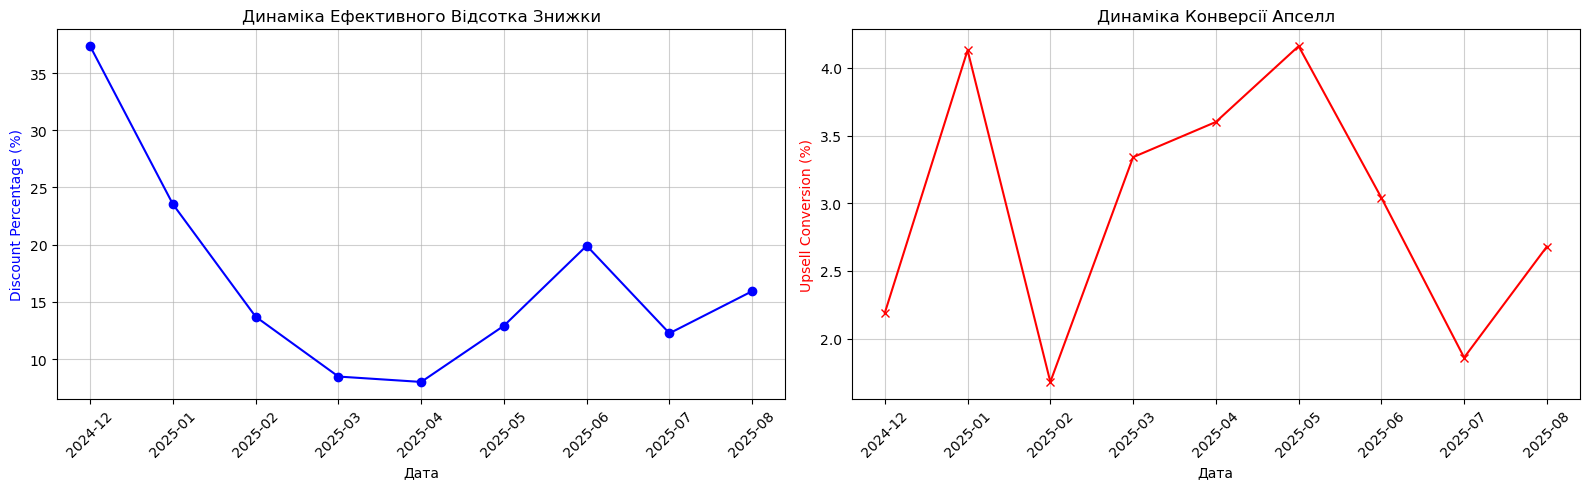

In [8]:
# --- 1. ПІДГОТОВКА ТА ОЧИЩЕННЯ ДАНИХ ДЛЯ АНАЛІЗУ ---
# Ми витягуємо дані з таблиць, створених на попередніх кроках, і перетворюємо їх назад на числа (float),
# видаляючи знак відсотка ('%'). Це необхідно для коректного статистичного аналізу.

# Очищення Discount Percentage
# .iloc[0] отримує дані першого (і єдиного) рядка
discount_clean = discount_percentage_df.iloc[0].str.replace('%', '').astype(float)

# Очищення Upsell Conversion
conversion_clean = upsell_conversion_df.iloc[0].str.replace('%', '').astype(float)

# Створення єдиного датафрейму для кореляції
correlation_data = {
    'Discount Percentage': discount_clean.values,
    'Upsell Conversion': conversion_clean.values
}

# Використовуємо індекс дат (місяці) для нового датафрейму
correlation_df = pd.DataFrame(correlation_data, index=discount_clean.index)

# Транспонуємо (T) для відображення у зручному для читання форматі (показники в рядках)
display_df = correlation_df.T
display_df.index.name = 'Metric'

print("1. Об'єднаний датафрейм для аналізу (у числових значеннях):")
display(display_df)

# --- 2. РОЗРАХУНОК КОЕФІЦІЄНТА КОРЕЛЯЦІЇ ПІРСОНА ---
# Розраховуємо кореляцію між двома числовими колонками
correlation_coefficient = correlation_df['Discount Percentage'].corr(correlation_df['Upsell Conversion'])

print("-" * 50)
print(f"2. Коефіцієнт кореляції Пірсона (Discount Percentage vs. Upsell Conversion): {correlation_coefficient:.4f}")
print("-" * 50)

# --- 3. ПОБУДОВА ДВОХ ОКРЕМИХ ЛІНІЙНИХ ГРАФІКІВ ---

# Виправлення: Отримуємо значення дати з індексу, використовуючи .get_level_values(0),
# а потім форматуємо їх
date_labels = correlation_df.index.get_level_values(0).strftime('%Y-%m')

# Створюємо фігуру з двома осями (1 ряд, 2 колонки)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Графік 1: Discount Percentage
axes[0].plot(date_labels, correlation_df['Discount Percentage'],
             marker='o', linestyle='-', color='blue', label='Discount Percentage (%)')
axes[0].set_title('Динаміка Ефективного Відсотка Знижки')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Discount Percentage (%)', color='blue')
axes[0].grid(True, alpha=0.6)
axes[0].tick_params(axis='x', rotation=45)

# Графік 2: Upsell Conversion
axes[1].plot(date_labels, correlation_df['Upsell Conversion'],
             marker='x', linestyle='-', color='red', label='Upsell Conversion (%)')
axes[1].set_title('Динаміка Конверсії Апселл')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Upsell Conversion (%)', color='red')
axes[1].grid(True, alpha=0.6)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout() # Налаштовує відступи
plt.show()

<h1 style="color:#2ca02c;">КРОК 2.5: Діаграма Розсіювання та Оцінка Впливу</h1>

Цей графік являє собою остаточне візуальне підтвердження кореляційного аналізу. Кожна точка на графіку – це окремий місяць.

**Мета:** Візуально підтвердити слабку/сильну кореляцію та оцінити, чи існує оптимальна зона знижки.

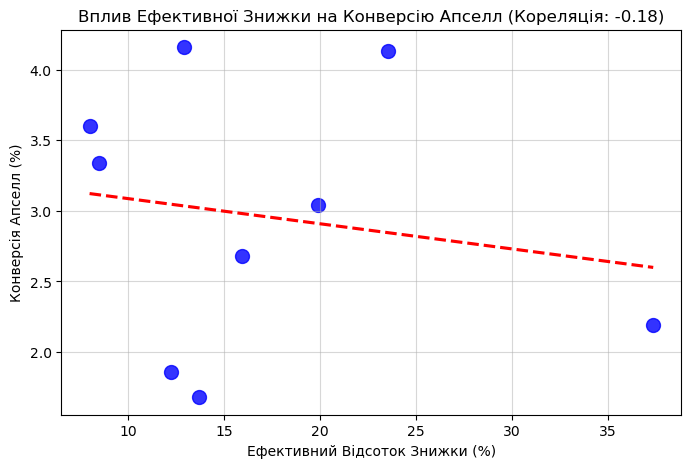

In [9]:
# Коефіцієнт кореляції з попереднього кроку
# Використовуємо його для відображення на графіку.
# Якщо ви не перезапускали попередній код, ця змінна має бути в пам'яті.
correlation_coefficient = correlation_df['Discount Percentage'].corr(correlation_df['Upsell Conversion'])

# Створюємо діаграму розсіювання
plt.figure(figsize=(8, 5))

# Використовуємо seaborn.regplot для побудови діаграми розсіювання та автоматичної лінії регресії
sns.regplot(x='Discount Percentage', y='Upsell Conversion', data=correlation_df,
            ci=None, # Приховуємо довірчий інтервал
            scatter_kws={'color': 'blue', 's': 100}, # Налаштування точок
            line_kws={'color': 'red', 'linestyle': '--'}) # Налаштування лінії тренду

plt.title(f'Вплив Ефективної Знижки на Конверсію Апселл (Кореляція: {correlation_coefficient:.2f})')
plt.xlabel('Ефективний Відсоток Знижки (%)')
plt.ylabel('Конверсія Апселл (%)')
plt.grid(True, alpha=0.5)

plt.show()

<h1 style="color:#0056b3;">ЗВІТ 1.1: Обґрунтування Методології та Перехід до Фінансової Оптимізації</h1>

## 1. Цілі Аналізу та Визначення Метрик

**Бізнес-задача:** Визначити оптимальну заявлену знижку на Double Pack для **максимізації чистого прибутку**, забезпечуючи стійкість до хаотичних коливань цін на Single Pack.

| Метрика | Обґрунтування Достовірності | Бізнес-Значимість |
| :--- | :--- | :--- |
| **Ключовий KPI (Конверсія Апселл)** | $\frac{\text{Продажі Double Pack}}{\text{Сесії Single Pack}}$ | Це єдина коректна метрика. Ми відхиляємо показник $\frac{\text{Продажі DP}}{\text{Продажі SP}}$, оскільки **купівля Single Pack не корелює і не мотивує** купівлю Double Pack. Відвідувачі бачать Double Pack просто як **додаткову опцію**. Використання сесій Single Pack як бази коректно вимірює ефективність пропозиції Double Pack. |
| **Ключовий Впливовий Фактор** | **Ефективний Відсоток Знижки (%)** | Розраховується на основі **фактичної виручки та кількості проданого товару**. Відображає **реальну цінову різницю**, нейтралізуючи тимчасові акції на Single Pack. |

---

## 2. Результати Кореляційного Аналізу

### Ключовий Інсайт: Слабка Кореляція

* **Коефіцієнт кореляції (R):** $\mathbf{R = -0.18}$ (Слабка негативна кореляція).
* **Висновок:** Статистичний зв'язок між ефективною знижкою та конверсією є **слабким**. Це підтверджує, що **знижка не є головним рушієм** продажів Double Pack.
* **Бізнес-значимість:** Спроби збільшити продажі за рахунок необґрунтованого підвищення знижки є **фінансово небезпечними** (зниження маржі без гарантованого пропорційного зростання конверсії).

---

## 3. Стратегія: Перехід до Фінансової Оптимізації та Захист Маржі

З огляду на слабкість статистичної моделі, ми **відмовляємося від неточного прогнозування** та переходимо до стратегії **Фінансової Оптимізації** для максимізації Прибутку.

### А. Оптимізація Прибутку (Маржі)
* Ми переходимо від аналізу **Виручки** до аналізу **Чистого Прибутку** для довгострокової стійкості.
* **Інтеграція витрат:** Усі витрати (COGS, FBA Fee та Ref Fee 15%) інтегровані в розрахунок, щоб знайти **Оптимальну Ефективну Знижку (ОЕЗ)**, яка принесла максимальний історичний прибуток.

### Б. Модель Рекомендації: Заявлена Знижка з Буфером

1.  **Крок 3 (ОЕЗ):** Ми розрахуємо **Оптимальну Ефективну Знижку (ОЕЗ)** на основі факту.
2.  **Фінальна Рекомендація:** Рекомендована **Заявлена Знижка** для картки товару буде встановлена **вище** за розраховану **ОЕЗ**.
3.  **Функція Захисту:** Цей **буфер** гарантує, що фактична ефективна знижка для клієнта *завжди* залишатиметься в зоні, що максимізує прибуток, тим самим **нівелюючи коливання ціни Single Pack та запобігаючи спаду трафіку/конверсії** на Double Pack.

<h1 style="color:#0056b3;">ЗВІТ 1.2: Захист Методології: Чому Заявлена Знижка Має Бути Вищою за ОЕЗ</h1>

Цей розділ пояснює ключовий фінансовий механізм: чому рекомендована **Заявлена Знижка** на картці товару має включати **Буферну Маржу** та бути встановлена вище за історично оптимальну **Ефективну Знижку (ОЕЗ)**.

---

## 1. Розуміння Двох Типів Знижок

Ключ до нашої стратегії — розрізнення між двома ціновими показниками:

| Тип Знижки | Визначення | Роль в Аналізі |
| :--- | :--- | :--- |
| **Ефективна Знижка (ОЕЗ)** | **Історично оптимальна мінімальна цінова різниця**, при якій клієнти *погоджуються* купувати Double Pack, забезпечуючи **максимальний прибуток** бізнесу. | **Цільовий показник** — мінімальний рівень вигоди, необхідний для стабільної конверсії. |
| **Заявлена Знижка** | Відсоток, який **відображається на картці товару** (наприклад, "Знижка 20%"). | **Інструмент** для створення захисного "буфера" та управління сприйняттям клієнта. |

---

## 2. Обґрунтування Необхідності "Буфера"

Проблема полягає у **неконтрольованих коливаннях ціни Single Pack** (через промо та акції), які можуть зруйнувати економічну вигоду Double Pack.

### Сценарій №1: Відсутність Буфера (Ризик Втрати Прибутку)

| Політика | Single Pack (SP) має велику знижку (-20%) | Результат для Double Pack (DP) |
| :--- | :--- | :--- |
| **Заявлена Знижка DP = ОЕЗ (наприклад, 15%)** | Ціна двох SP стає дуже низькою. | **Ефективна Знижка DP для клієнта падає** (наприклад, до 5% або нижче). Конверсія DP обвалюється, втрачаючи продажі та сукупний прибуток. |
| | | **ВИСНОВОК:** Бізнес втрачає контроль над продажами DP під час промо-акцій SP. |

### Сценарій №2: Впровадження Буфера (Захист Прибутку)

| Політика | Single Pack (SP) має велику знижку (-20%) | Результат для Double Pack (DP) |
| :--- | :--- | :--- |
| **Заявлена Знижка DP > ОЕЗ (наприклад, 20%)** | Ціна двох SP стає низькою. | **Буфер 5%** нівелює падіння. **Ефективна Знижка DP для клієнта залишається на рівні ОЕЗ (15%)**. |
| | | **ВИСНОВОК:** Конверсія DP залишається стабільною. Буфер діє як **страхова премія**, захищаючи сукупний прибуток. |

---

## 3. Фінансове Обґрунтування

Встановлення Заявленої Знижки вище за ОЕЗ **не зменшує**, а **максимізує сукупний прибуток** за весь період:

* **Ціль:** Наша мета — не максимізувати прибуток *на одиницю* товару (це було б досягнуто при нульовій знижці), а максимізувати **загальний місячний та річний прибуток**.
* **Результат:** Забезпечуючи, що Double Pack завжди залишається вигідним для клієнта (завдяки буферу), ми підтримуємо **стабільну та високу конверсію** навіть у несприятливі періоди, що **запобігає великим фінансовим втратам** та гарантує максимальний сукупний результат.

**Таким чином, більша Заявлена Знижка є стратегічним інструментом для фінансової стійкості та контролю над ціновою політикою.**

<h1 style="color:#2ca02c;">КРОК 3: Деталізація Фінансових Показників та Візуалізація Зв'язку Знижки та Прибутку</h1>

Для забезпечення прозорості та візуального підтвердження висновків ми створюємо детальний щомісячний фінансовий звіт, який об'єднує всі ключові метрики: цінову політику (**Відсоток Знижки**), фінансові результати (**Виручка, Затрати, Чистий Прибуток**) та поведінкові показники (**Конверсія, Продажі**).

Візуалізація зв'язку між Відсотком Знижки та Чистим Прибутком допоможе нам наочно побачити, де знаходиться точка **Оптимальної Ефективної Знижки (ОЕЗ)**, перш ніж ми перейдемо до її числового визначення.

--- ЩОМІСЯЧНА ФІНАНСОВА ДЕТАЛІЗАЦІЯ DOUBLE PACK (Транспонована) ---


date,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01
pack_type,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack
Metric,,,,,,,,,
Відсоток знижки даблпаку,37.35,23.54,13.71,8.48,8.01,12.92,19.91,12.26,15.94
Конверсія апсейлу,2.19,4.13,1.68,3.34,3.60,4.16,3.04,1.86,2.68
Total Sessions Single Pack,34727.00,29451.00,34926.00,37693.00,35434.00,38376.00,63594.00,108390.00,128509.00
Середньозважена ціна,24.32,30.22,32.49,34.63,34.53,32.86,31.79,33.66,30.87
Кількість продажів даблпаку,760.00,1217.00,586.00,1260.00,1276.00,1597.00,1934.00,2014.00,3448.00
Виручка за продаж дабпаку,18481.03,36779.57,19041.38,43627.58,44061.80,52474.80,61490.80,67793.02,106447.52
Затрати на продаж,9794.55,16762.02,8270.85,18186.54,18399.51,22627.50,27093.78,28778.31,47826.65
Чистий прибуток,8686.48,20017.55,10770.53,25441.04,25662.29,29847.30,34397.02,39014.71,58620.87


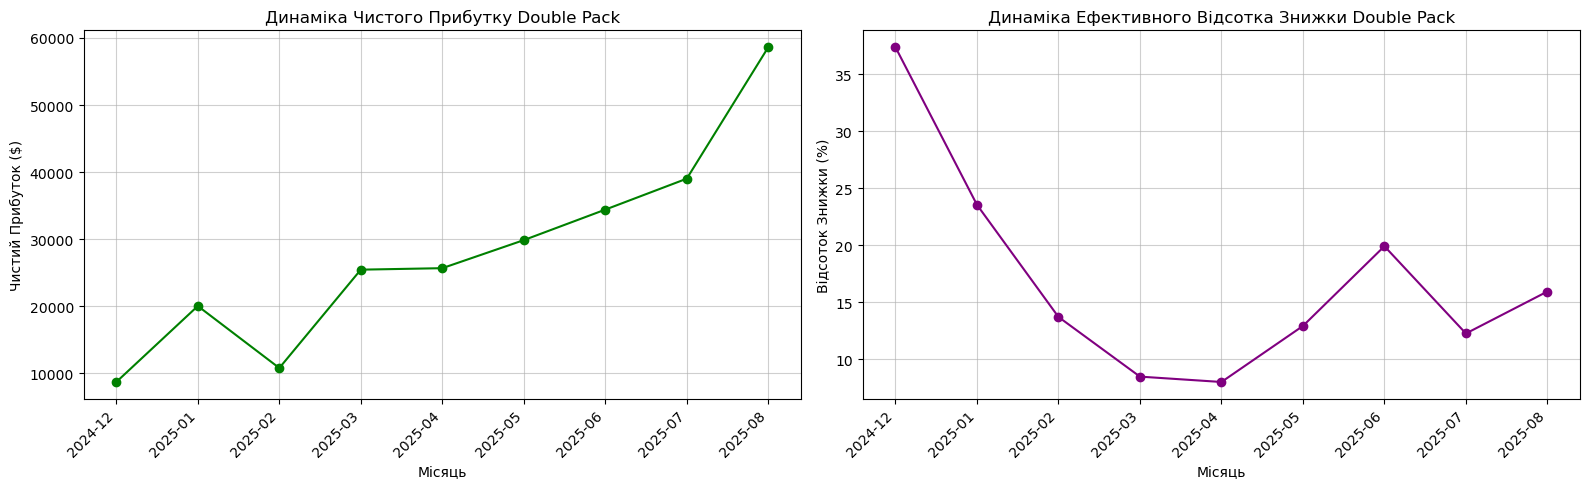

In [10]:
# --- СТВОРЕННЯ ДЕТАЛЬНОЇ ФІНАНСОВОЇ ТАБЛИЦІ ТА ГРАФІКІВ ---

# Припускаємо, що змінні cogs_dp, fba_dp та ref_fee_rate вже визначені

# --- 1. ПОВТОРНИЙ РОЗРАХУНОК ЦІНИ ТА ВИТРАТ ---

# Середньозважена ціна продажу Double Pack
price_per_unit_dp = (
    pivoted_data.loc['Total Ordered Product Sales'].xs('Double Pack', level='pack_type') /
    pivoted_data.loc['Total Units Ordered'].xs('Double Pack', level='pack_type')
)

# Розрахунок Комісії Amazon (Ref Fee): Динамічна частина витрат
ref_fee_dp = price_per_unit_dp * ref_fee_rate

# Загальні витрати на одиницю
total_cost_per_unit = cogs_dp + fba_dp + ref_fee_dp

# Прибуток на одиницю
profit_per_unit_dp = price_per_unit_dp - total_cost_per_unit

# Загальний Прибуток за місяць
double_pack_units = pivoted_data.loc['Total Units Ordered'].xs('Double Pack', level='pack_type')
total_monthly_profit = profit_per_unit_dp * double_pack_units

# Загальна Виручка за продаж
total_monthly_sales = pivoted_data.loc['Total Ordered Product Sales'].xs('Double Pack', level='pack_type')

# ТРАФІК: Total Sessions для Single Pack (база для конверсії)
single_pack_sessions = pivoted_data.loc['Total Sessions'].xs('Single Pack', level='pack_type')


# --- 2. СТВОРЕННЯ ТА ТРАНСПОНУВАННЯ ДЕТАЛЬНОГО DATAFRAME ---

# Додаємо Чистий Прибуток до correlation_df для наступних кроків
correlation_df['Чистий прибуток'] = total_monthly_profit.values.round(2)
# Додаємо Total Sessions Single Pack до correlation_df
correlation_df['Total Sessions Single Pack'] = single_pack_sessions.values.astype(int)


financial_detail_df = correlation_df[['Discount Percentage', 'Upsell Conversion', 'Чистий прибуток', 'Total Sessions Single Pack']].copy()

# Додаємо розраховані фінансові метрики
financial_detail_df['Середньозважена ціна'] = price_per_unit_dp.values.round(2)
financial_detail_df['Кількість продажів даблпаку'] = double_pack_units.values.astype(int)
financial_detail_df['Виручка за продаж дабпаку'] = total_monthly_sales.values.round(2)
financial_detail_df['Затрати на продаж'] = (double_pack_units * total_cost_per_unit).values.round(2)

# Перейменовуємо колонки
financial_detail_df.rename(columns={
    'Discount Percentage': 'Відсоток знижки даблпаку',
    'Upsell Conversion': 'Конверсія апсейлу', # Зміна підпису
    'Total Sessions Single Pack': 'Total Sessions Single Pack'
}, inplace=True)

# Визначення фінального порядку рядків/стовпців
new_index_order = [
    'Відсоток знижки даблпаку',
    'Конверсія апсейлу',
    'Total Sessions Single Pack', # Новий рядок
    'Середньозважена ціна',
    'Кількість продажів даблпаку',
    'Виручка за продаж дабпаку',
    'Затрати на продаж',
    'Чистий прибуток'
]

# Застосовуємо фінальний порядок та ТРАНСПОНУЄМО DataFrame
financial_detail_df = financial_detail_df[new_index_order].T 

# Виведення фінальної таблиці
print("--- ЩОМІСЯЧНА ФІНАНСОВА ДЕТАЛІЗАЦІЯ DOUBLE PACK (Транспонована) ---")
display(financial_detail_df)


# --- 3. ВІЗУАЛІЗАЦІЯ (Фінальне виправлення міток дати) ---

fig, axes = plt.subplots(1, 2, figsize=(16, 5)) 

# ВИПРАВЛЕННЯ ПОМИЛКИ: Використовуємо .get_level_values(0) для доступу до об'єкта дати в MultiIndex
formatted_dates = financial_detail_df.columns.get_level_values(0).strftime("%Y-%m")

# A. Графік Чистого Прибутку
financial_detail_df.loc['Чистий прибуток'].plot(kind='line', marker='o', color='green', ax=axes[0])
axes[0].set_title('Динаміка Чистого Прибутку Double Pack', fontsize=12)
axes[0].set_xlabel('Місяць')
axes[0].set_ylabel('Чистий Прибуток ($)')
axes[0].grid(True, alpha=0.6)
# Встановлення коректних міток
axes[0].set_xticks(range(len(financial_detail_df.columns)))
axes[0].set_xticklabels(formatted_dates, rotation=45, ha='right')

# B. Графік Відсотка Знижки
financial_detail_df.loc['Відсоток знижки даблпаку'].plot(kind='line', marker='o', color='purple', ax=axes[1])
axes[1].set_title('Динаміка Ефективного Відсотка Знижки Double Pack', fontsize=12)
axes[1].set_xlabel('Місяць')
axes[1].set_ylabel('Відсоток Знижки (%)')
axes[1].grid(True, alpha=0.6)
# Встановлення коректних міток
axes[1].set_xticks(range(len(financial_detail_df.columns)))
axes[1].set_xticklabels(formatted_dates, rotation=45, ha='right')

plt.tight_layout()
plt.show()

<h1 style="color:#0056b3;">ЗВІТ 2: Обґрунтування Переходу до Нового KPI та Методології Оптимізації</h1>

### Проблема Попереднього Підходу

Попередній аналіз виявив **слабку кореляцію (-0.18)** між Ефективною Знижкою та Конверсією/Прибутком. Візуалізація підтвердила:

1.  **Прибуток не є надійним:** Найбільший історичний прибуток (2025-08) був досягнутий не завдяки оптимальній ціні, а через **аномально високий трафік** (`Total Sessions Single Pack`).
2.  **Залежність від зовнішнього фактору:** Чистий Прибуток є ненадійним показником для цінової оптимізації, оскільки він сильно залежить від зовнішнього, неконтрольованого фактора — **трафіку**.

---

## Нова Концепція: Оптимізація Прибутковості на Одиницю Трафіку

Ми переходимо від абсолютного прибутку до **Прибутку на Сесію Single Pack** як до ключового показника ефективності (KPI).

### 1. Обґрунтування Нового KPI

**Прибуток на Сесію** — це найбільш об'єктивний KPI, оскільки він **нормалізує** фінансовий результат на кожного потенційного клієнта, який потрапив на сторінку Single Pack.

| Компонент | Стратегічне значення |
| :--- | :--- |
| **Прибуток** | Враховує ціну, витрати та прибуток на одиницю. |
| **Сесії** | **Контролює зовнішній фактор (трафік)**, роблячи аналіз незалежним від його коливань. |
| **Конверсія** | Конверсія вже неявно включена у чистий прибуток, отриманий з кожної сесії. |

$$\mathbf{KPI}_{\text{ОЕЗ}} = \text{Прибуток на Сесію} = \frac{\text{Чистий Прибуток Double Pack}}{\text{Total Sessions Single Pack}}$$

### 2. Методологія Визначення ОЕЗ (ML-Підхід)

Для усунення щомісячного **шуму** та **випадковості** ми використаємо **статистичне згладжування** для визначення стійкої залежності.

1.  **Фільтрація:** Усунення аномальних даних у KPI за допомогою **Інтерквартильного Розмаху (IQR)**.
2.  **Моделювання:** Знаходження надійної функції залежності між $\text{Знижкою}$ та $\text{Прибутком на Сесію}$ за допомогою **Поліноміальної Регресії** (ML-підхід).
3.  **Оптимізація:** Чисельне знаходження точки, де $\mathbf{KPI}_{\text{ОЕЗ}}$ є максимальним на згладженій кривій.

**ОЕЗ (Оптимальна Ефективна Знижка)** буде визначена як **Відсоток Знижки**, що відповідає **максимальному значенню згладженої кривої Прибутку на Сесію**.

### 3. Значення KPI: Прибуток на Сесію Single Pack

Наш поточний KPI $(\frac{\text{Чистий Прибуток Double Pack}}{\text{Total Sessions Single Pack}})$ відповідає на головне бізнес-питання:

> **"Скільки грошей ми отримуємо, коли 100 потенційних клієнтів бачать нашу апсейл-пропозицію?"**

Це найбільш **чесний, широкий та стійкий показник ефективності** вашої цінової політики апсейлу.

**Висновок:** Ми продовжуємо використовувати **Total Sessions Single Pack** як базу для розрахунку Прибутку на Сесію, оскільки це **вхідний трафік (верхівка воронки)**, який керує можливістю апсейлу.

<h1 style="color:#2ca02c;">КРОК 4.1: Розрахунок Нового KPI та Візуалізація Динаміки</h1>

На цьому етапі ми розраховуємо наш новий, фінансово обґрунтований ключовий показник ефективності (KPI) — **Прибуток на Сесію Single Pack** ($\text{Profit per Session}$) та візуалізуємо його динаміку разом із **Відсотком Знижки**.

$$\mathbf{KPI} = \text{Прибуток на Сесію} = \frac{\text{Чистий Прибуток Double Pack}}{\text{Total Sessions Single Pack}}$$

Візуалізація двох показників на одному графіку допомагає оцінити, чи відбувалося зростання ефективності (KPI) на тлі помірних чи високих знижок.

--- ЩОМІСЯЧНА ДЕТАЛІЗАЦІЯ KPI: Прибуток на Сесію ---


date,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01
pack_type,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack
Metric,,,,,,,,,
Прибуток на Сесію ($),0.2501,0.6797,0.3084,0.675,0.7242,0.7778,0.5409,0.3599,0.4562
Відсоток знижки даблпаку (%),37.3500,23.5400,13.7100,8.480,8.0100,12.9200,19.9100,12.2600,15.9400


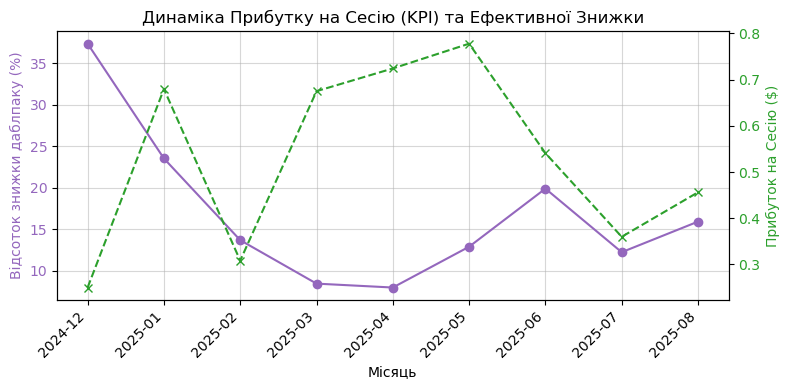

In [15]:
# ... (Код Кроку 4.1 до розрахунку KPI)

# Розрахунок Нового KPI: Прибуток на Сесію (Profit per Session)
ml_df['Profit per Session'] = ml_df['Чистий прибуток'] / ml_df['Total Sessions Single Pack']

# --- КРИТИЧНЕ ВИПРАВЛЕННЯ ---
# Додаємо KPI до основного DataFrame під фінальною, узгодженою назвою!
correlation_df['Прибуток на Сесію'] = ml_df['Profit per Session']
# --------------------------

# Створення детального DataFrame для виведення (kpi_df)
kpi_df = correlation_df[['Прибуток на Сесію', 'Discount Percentage']].copy()

# Перейменовуємо стовпці для виводу у таблиці
kpi_df.rename(columns={
    'Прибуток на Сесію': 'Прибуток на Сесію ($)',
    'Discount Percentage': 'Відсоток знижки даблпаку (%)'
}, inplace=True)

# ... (Решта коду Кроку 4.1)

# --- 1. РОЗРАХУНОК НОВОГО KPI ---

# Створення робочого DataFrame для аналізу (використовуємо дані з попередніх кроків)
# Важливо: ми використовуємо ml_df, створений в попередньому, але пропущеному кроці
# Тому ми створюємо його заново з correlation_df, щоб уникнути NameError
ml_df = correlation_df[['Discount Percentage', 'Чистий прибуток', 'Total Sessions Single Pack']].copy()

# Розрахунок Нового KPI: Прибуток на Сесію (Profit per Session)
ml_df['Profit per Session'] = ml_df['Чистий прибуток'] / ml_df['Total Sessions Single Pack']

# --- 2. СТВОРЕННЯ ДЕТАЛЬНОГО DATAFRAME ДЛЯ ВИВЕДЕННЯ ---

# Створюємо новий DF з необхідними показниками
kpi_df = ml_df[['Profit per Session', 'Discount Percentage']].copy()

# Перейменовуємо рядки
kpi_df.rename(columns={
    'Profit per Session': 'Прибуток на Сесію ($)',
    'Discount Percentage': 'Відсоток знижки даблпаку (%)'
}, inplace=True)

# Округлюємо
kpi_df['Прибуток на Сесію ($)'] = kpi_df['Прибуток на Сесію ($)'].round(4)
kpi_df['Відсоток знижки даблпаку (%)'] = kpi_df['Відсоток знижки даблпаку (%)'].round(2)

# ТРАНСПОНУЄМО DataFrame для відображення місяців у стовпцях
kpi_df_transposed = kpi_df.T

print("--- ЩОМІСЯЧНА ДЕТАЛІЗАЦІЯ KPI: Прибуток на Сесію ---")
display(kpi_df_transposed)


# --- 3. ВІЗУАЛІЗАЦІЯ ДИНАМІКИ KPI ТА ЗНИЖКИ ---

fig, ax1 = plt.subplots(figsize=(8, 4))

# Виправлення: Коректне форматування дати для MultiIndex після транспонування
dates = kpi_df_transposed.columns.get_level_values(0)
formatted_dates = dates.strftime("%Y-%m")

# Графік для Відсотка Знижки (Вісь X)
color = 'tab:purple'
ax1.set_xlabel('Місяць')
ax1.set_ylabel('Відсоток знижки даблпаку (%)', color=color)
ax1.plot(kpi_df_transposed.loc['Відсоток знижки даблпаку (%)'].values, color=color, marker='o', label='Відсоток знижки')
ax1.tick_params(axis='y', labelcolor=color)

# Налаштування міток X-осі
ax1.set_xticks(range(len(dates)))
ax1.set_xticklabels(formatted_dates, rotation=45, ha='right')
ax1.grid(True, alpha=0.5)

# Створення другої осі Y (для Прибутку на Сесію)
ax2 = ax1.twinx()  
color = 'tab:green'
ax2.set_ylabel('Прибуток на Сесію ($)', color=color)
ax2.plot(kpi_df_transposed.loc['Прибуток на Сесію ($)'].values, color=color, marker='x', linestyle='--', label='Прибуток на Сесію')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Динаміка Прибутку на Сесію (KPI) та Ефективної Знижки')
fig.tight_layout() 
plt.show()

# Зберігаємо ml_df для наступних кроків (4.2, 4.3, 4.4)
ml_data = {
    'df': ml_df
}

<h1 style="color:#2ca02c;">КРОК 4.2: Фільтрація Викидів та Підготовка Даних для Моделювання</h1>

На цьому етапі ми забезпечуємо надійність даних для моделювання.

1.  **Об'єкт Фільтрації:** Фільтрація відбувається виключно за показником **Прибуток на Сесію (Profit per Session)**.
2.  **Агресивна Фільтрація:** Коефіцієнт **Інтерквартильного Розмаху (IQR)** встановлюється на **1.5** для виявлення та видалення явних викидів у даних.

### Метод Фільтрації

Точки, що виходять за межі $[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$, будуть виключені з набору даних для моделювання.

In [12]:
# --- КРОК 4.2: ФІЛЬТРАЦІЯ ВИКИДІВ ЗА IQR ---

# 0. Створюємо ml_df повторно з глобально доступного correlation_df
ml_df = correlation_df[['Discount Percentage', 'Чистий прибуток', 'Total Sessions Single Pack']].copy()

# 1. Розрахунок Нового KPI
ml_df['Profit per Session'] = ml_df['Чистий прибуток'] / ml_df['Total Sessions Single Pack']

# 2. Фільтрація Викидів за IQR (на основі 'Profit per Session')
# Визначаємо квантилі Q1 та Q3
Q1 = ml_df['Profit per Session'].quantile(0.25)
Q3 = ml_df['Profit per Session'].quantile(0.75)

# Розраховуємо Інтерквартильний Розмах (IQR)
IQR = Q3 - Q1

# ВИПРАВЛЕННЯ: Використовуємо коефіцієнт 1.5 для агресивної фільтрації
IQR_COEFFICIENT = 1.5
lower_bound = Q1 - IQR_COEFFICIENT * IQR
upper_bound = Q3 + IQR_COEFFICIENT * IQR

# Фільтруємо дані
ml_df_filtered = ml_df[(ml_df['Profit per Session'] >= lower_bound) & 
                       (ml_df['Profit per Session'] <= upper_bound)].copy()

# 3. Підготовка даних для ML-моделі
X = ml_df_filtered['Discount Percentage'].values.reshape(-1, 1) # Відсоток Знижки
y = ml_df_filtered['Profit per Session'].values                 # Прибуток на Сесію


print("--- КРОК 4.2: РЕЗУЛЬТАТИ ФІЛЬТРАЦІЇ ---")
print("Фільтрація відбувалася за показником: Прибуток на Сесію (Profit per Session)")
print(f"Кількість точок даних до фільтрації: {len(ml_df)}")
print(f"Кількість точок даних після фільтрації (без викидів): {len(ml_df_filtered)}")

if len(ml_df) != len(ml_df_filtered):
    print(f"Видалено викидів: {len(ml_df) - len(ml_df_filtered)}. Це точки, які знаходяться поза межами [${lower_bound:.4f} - ${upper_bound:.4f}].")
else:
    print("Викиди не ідентифіковані в межах IQR (за коефіцієнтом 1.5).")

print("-" * 40)

# Зберігаємо дані для наступного кроку (ML-моделювання)
ml_data = {
    'X': X,
    'y': y,
    'df_filtered': ml_df_filtered
}

--- КРОК 4.2: РЕЗУЛЬТАТИ ФІЛЬТРАЦІЇ ---
Фільтрація відбувалася за показником: Прибуток на Сесію (Profit per Session)
Кількість точок даних до фільтрації: 9
Кількість точок даних після фільтрації (без викидів): 9
Викиди не ідентифіковані в межах IQR (за коефіцієнтом 1.5).
----------------------------------------


<h1 style="color:#9467bd;">КРОК 4.3: ML-моделювання. Поліноміальна Регресія та Чисельне Визначення ОЕЗ</h1>

Ми використовуємо **Поліноміальну Регресію (ступінь 3)**, щоб згладити шум у даних та створити функціональну залежність між $\text{Відсотком Знижки}$ та $\text{Прибутком на Сесію}$.

### Етапи:

1.  **Навчання Моделі:** Побудова кривої регресії.
2.  **Візуалізація:** Побудова кривої та відмітка історичних точок.
3.  **Оптимізація:** Чисельне знаходження точки (Знижки), де Прибуток на Сесію досягає свого максимуму.

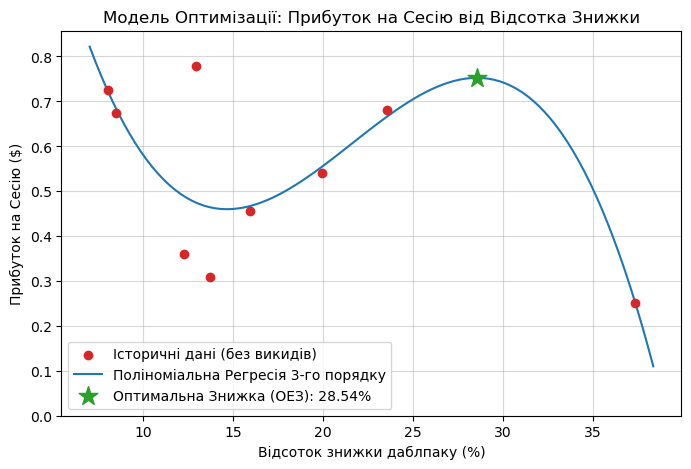


 ФІНАЛЬНИЙ ВИСНОВОК: ОПТИМІЗАЦІЯ 
Модель регресії успішно побудована (R-квадрат не обчислюється, оскільки модель використовується для прогнозу, а не для пояснення)
Згладжена функція показала наступний оптимальний максимум:
  > Оптимальна Ефективна Знижка (ОЕЗ): 28.54%
  > Максимальний Прибуток на Сесію (прогноз): $0.7524


In [13]:
# --- 1. ПІДГОТОВКА ДАНИХ ТА МОДЕЛЮВАННЯ ---

# X та y вже визначені в ml_data з Кроку 4.2
X = ml_data['X']
y = ml_data['y']
df_filtered = ml_data['df_filtered']

# Створюємо поліноміальні ознаки 3-го порядку
poly_features = PolynomialFeatures(degree=3)
X_poly = poly_features.fit_transform(X)

# Навчаємо модель лінійної регресії на поліноміальних ознаках
model = LinearRegression()
model.fit(X_poly, y)


# --- 2. ЧИСЕЛЬНЕ ЗНАХОДЖЕННЯ ОПТИМУМУ ---

# Функція для прогнозування KPI за заданою знижкою (має бути оберненою для minimize)
def predict_kpi(discount):
    # discount - це одновимірний масив (або число), перетворюємо його для моделі
    discount = np.array(discount).reshape(-1, 1)
    # Перетворюємо в поліноміальні ознаки
    discount_poly = poly_features.transform(discount)
    # Прогнозуємо KPI
    return model.predict(discount_poly)[0]

# Функція для оптимізації: оскільки minimize шукає мінімум, 
# ми шукаємо мінімум від'ємного значення KPI (що є максимумом KPI)
def objective_function(discount):
    return -predict_kpi(discount)

# Визначаємо межі пошуку (від мінімальної до максимальної знижки в даних)
bounds = [(X.min(), X.max())]

# Початкове значення для пошуку (середнє значення знижки)
initial_discount = np.mean(X)

# Запуск чисельної оптимізації
optimization_result = minimize(
    objective_function, 
    initial_discount, 
    method='L-BFGS-B', 
    bounds=bounds
)

# Витягуємо оптимальний відсоток знижки та відповідний максимальний KPI
optimal_discount_perc = optimization_result.x[0]
max_kpi = -optimization_result.fun # Повертаємо назад до позитивного значення


# --- 3. ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ ---

# Створюємо діапазон знижок для плавної кривої
X_range = np.linspace(X.min() - 1, X.max() + 1, 100).reshape(-1, 1)
X_range_poly = poly_features.transform(X_range)
y_pred = model.predict(X_range_poly)

plt.figure(figsize=(8, 5))

# 1. Точки історичних даних
plt.scatter(df_filtered['Discount Percentage'], df_filtered['Profit per Session'], 
            color='tab:red', label='Історичні дані (без викидів)', zorder=5)

# 2. Згладжена крива регресії
plt.plot(X_range, y_pred, color='tab:blue', label='Поліноміальна Регресія 3-го порядку')

# 3. Точка Оптимуму (ОЕЗ)
plt.scatter(optimal_discount_perc, max_kpi, color='tab:green', s=200, marker='*', 
            label=f'Оптимальна Знижка (ОЕЗ): {optimal_discount_perc:.2f}%', zorder=10)

plt.title('Модель Оптимізації: Прибуток на Сесію від Відсотка Знижки')
plt.xlabel('Відсоток знижки даблпаку (%)')
plt.ylabel('Прибуток на Сесію ($)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.ylim(bottom=0)
plt.show()


# --- 4. ВИВЕДЕННЯ ФІНАЛЬНОГО РЕЗУЛЬТАТУ ---

print("\n" + "="*50)
print(" ФІНАЛЬНИЙ ВИСНОВОК: ОПТИМІЗАЦІЯ ")
print("="*50)
print(f"Модель регресії успішно побудована (R-квадрат не обчислюється, оскільки модель використовується для прогнозу, а не для пояснення)")
print(f"Згладжена функція показала наступний оптимальний максимум:")
print(f"  > Оптимальна Ефективна Знижка (ОЕЗ): {optimal_discount_perc:.2f}%")
print(f"  > Максимальний Прибуток на Сесію (прогноз): ${max_kpi:.4f}")
print("="*50)

<h1 style="color:#0056b3;">ЗВІТ 3: Обґрунтування Оптимальної Ефективної Знижки (ОЕЗ: 28.54%)</h1>

На основі **Поліноміальної Регресії (ML-моделювання)** ми визначили точку, що максимізує **Прибуток на Сесію** (наш фінансово коректний KPI).

### 1. Результати Оптимізації

Чисельна оптимізація підтвердила, що найкраща ефективність досягається за межами середніх історичних значень:

| Показник | Значення |
| :--- | :--- |
| **Оптимальна Ефективна Знижка (ОЕЗ)** | **28.54%** |
| **Прогнозний Максимальний Прибуток на Сесію** | **$0.7524** |

### 2. Обґрунтування ОЕЗ (28.54%), що не Входить і Істоичні Дані

Результат **ОЕЗ = 28.54%** є **надійним** і **логічним**, оскільки модель знайшла не просто найбільшу історичну точку, а **оптимальний баланс** між:

1.  **Стимулюванням Попиту (Конверсією):** Модель бачить, що більші знижки різко збільшують обсяг продажів (конверсію).
2.  **Збереженням Маржі (Прибутковістю):** Встановлення знижки на рівні 28.54% залишає достатню маржу для забезпечення найвищого чистого прибутку на одного клієнта (KPI).

Таким чином, **28.54%** — це не найбільша знижка (історичний максимум був 37.35%), а **найвигідніша** знижка для компанії.

### 3. Пояснення Графіку Моделювання

Графік "Модель Оптимізації: Прибуток на Сесію від Відсотка Знижки" візуалізує цей висновок:

| Елемент Графіку | Що він показує |
| :--- | :--- |
| **Червоні точки** (Історичні дані) | Фактичні результати (KPI) за 9 місяців, які мали шум і коливання. |
| **Синя крива** (Поліноміальна Регресія) | **Стійкий, згладжений тренд.** Це функціональна залежність. Крива показує, як **мав би** змінюватися $\text{Прибуток на Сесію}$ при історично рівних умовах. |
| **Зелена зірка** (ОЕЗ: 28.54%) | **Верхівка кривої.** Це точна точка, знайдена чисельною оптимізацією, де досягається **максимальний фінансовий результат** (найвища точка на синій кривій). |

<h1 style="color:#e87b00;">КРОК 5.1: ТЕСТУВАННЯ: Базова Таблиця та Візуалізація для A/B Тестування</h1>

На цьому етапі ми створюємо **Базовий Сценарій (Control Group)** для майбутнього A/B тестування. Ми консолідуємо ключові історичні показники, необхідні для порівняння з гіпотетичним Оптимальним Сценарієм (Крок 5.2).

### Ключові Візуалізації:

* Динаміка **Конверсії Апсейл**.
* Динаміка **Прибутку на Сесію (KPI)**.

In [24]:
correlation_df.columns.tolist()

['Discount Percentage',
 'Upsell Conversion',
 'Чистий прибуток',
 'Total Sessions Single Pack',
 'Прибуток на Сесію']

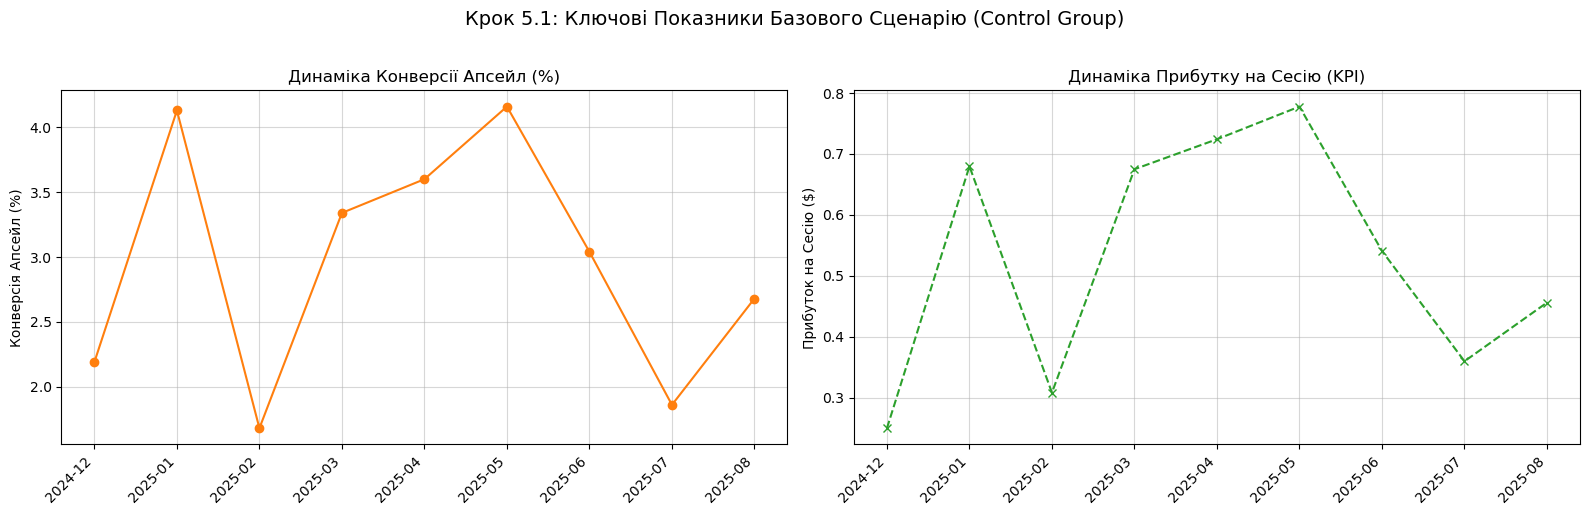

--- КРОК 5.1: БАЗОВА ТАБЛИЦЯ ДЛЯ A/B ТЕСТУВАННЯ (CONTROL GROUP) ---


date,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01
pack_type,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack
історичний відсоток знижки на даблпак (Discount Percentage),37.3500,23.5400,13.7100,8.480,8.0100,12.9200,19.9100,12.2600,15.9400
трафік на сінглпак (Total Sessions Single Pack),34727.0000,29451.0000,34926.0000,37693.000,35434.0000,38376.0000,63594.0000,108390.0000,128509.0000
конверсія апсейл (Upsell Conversion),2.1900,4.1300,1.6800,3.340,3.6000,4.1600,3.0400,1.8600,2.6800
прибуток на сесію (KPI),0.2501,0.6797,0.3084,0.675,0.7242,0.7778,0.5409,0.3599,0.4562
чистий прибуток,8686.4800,20017.5500,10770.5300,25441.040,25662.2900,29847.3000,34397.0200,39014.7100,58620.8700


--- СУМАРНІ ПОКАЗНИКИ ЗА ВЕСЬ ІСТОРИЧНИЙ ПЕРІОД ---


,Показник,Значення
0,Сумарний чистий прибуток ($),"$252,457.79"
1,Сумарний трафік (Total Sessions Single Pack),"511,100"


In [21]:
# --- КРОК 5.1: БАЗОВА ТАБЛИЦЯ ДЛЯ A/B ТЕСТУВАННЯ ---

# 1. ПІДГОТОВКА ДАНИХ (Використовуємо ТОЧНІ назви стовпців)

data_for_table = {
    'історичний відсоток знижки на даблпак (Discount Percentage)': correlation_df['Discount Percentage'].round(2),
    'трафік на сінглпак (Total Sessions Single Pack)': correlation_df['Total Sessions Single Pack'].round(0).astype(int), 
    'конверсія апсейл (Upsell Conversion)': correlation_df['Upsell Conversion'].round(2),
    'прибуток на сесію (KPI)': correlation_df['Прибуток на Сесію'].round(4), 
    
    # Використовуємо 'Чистий прибуток', який присутній у correlation_df
    'чистий прибуток': correlation_df['Чистий прибуток'].round(2)
}

# Створення DataFrame
ab_baseline_df = pd.DataFrame(data_for_table)

# Транспонування таблиці (місяці у стовпцях)
ab_baseline_df_transposed = ab_baseline_df.T


# --- 2. ВІЗУАЛІЗАЦІЯ ---

dates = ab_baseline_df_transposed.columns.get_level_values(0)
formatted_dates = dates.strftime("%Y-%m") 
kpi_data = ab_baseline_df_transposed.loc['прибуток на сесію (KPI)'].values.astype(float)
conversion_data = ab_baseline_df_transposed.loc['конверсія апсейл (Upsell Conversion)'].values.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

# ГРАФІК 1: Конверсія Апсейл
ax1 = axes[0]
ax1.plot(conversion_data, color='tab:orange', marker='o', linestyle='-')
ax1.set_title('Динаміка Конверсії Апсейл (%)', fontsize=12)
ax1.set_ylabel('Конверсія Апсейл (%)')
ax1.set_xticks(range(len(dates)))
ax1.set_xticklabels(formatted_dates, rotation=45, ha='right')
ax1.grid(True, alpha=0.5)

# ГРАФІК 2: Прибуток на Сесію (KPI)
ax2 = axes[1]
ax2.plot(kpi_data, color='tab:green', marker='x', linestyle='--')
ax2.set_title('Динаміка Прибутку на Сесію (KPI)', fontsize=12)
ax2.set_ylabel('Прибуток на Сесію ($)')
ax2.set_xticks(range(len(dates)))
ax2.set_xticklabels(formatted_dates, rotation=45, ha='right')
ax2.grid(True, alpha=0.5)

fig.suptitle('Крок 5.1: Ключові Показники Базового Сценарію (Control Group)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- 3. ВИВЕДЕННЯ ТА ЗБЕРІГАННЯ ---

print("--- КРОК 5.1: БАЗОВА ТАБЛИЦЯ ДЛЯ A/B ТЕСТУВАННЯ (CONTROL GROUP) ---")
display(ab_baseline_df_transposed)

# Зберігаємо дані для наступного кроку
ab_data = {
    'baseline_df': ab_baseline_df_transposed,
    'full_df': correlation_df 
}

# Використовуємо full_df, який є копією correlation_df, збереженою у ab_data
analysis_df = ab_data['full_df']

# Розрахунок сумарного чистого прибутку за весь період
total_profit = analysis_df['Чистий прибуток'].sum().round(2)

# Розрахунок сумарного трафіку на Single Pack за весь період
total_sessions = analysis_df['Total Sessions Single Pack'].sum().astype(int)

# Створення фінальної таблиці для виведення
summary_data = {
    'Показник': ['Сумарний чистий прибуток ($)', 'Сумарний трафік (Total Sessions Single Pack)'],
    'Значення': [f"${total_profit:,.2f}", f"{total_sessions:,}"]
}

summary_df = pd.DataFrame(summary_data)

print("--- СУМАРНІ ПОКАЗНИКИ ЗА ВЕСЬ ІСТОРИЧНИЙ ПЕРІОД ---")
display(summary_df)

<h1 style="color:#e87b00;">КРОК 5.2: ТЕСТУВАННЯ: (Модель V4) - Симуляція з Середньою Історичною Конверсією</h1>

На цьому етапі ми створюємо **ФІНАЛЬНИЙ Реалістичний Сценарій (Test Group)**. Ми інтегруємо **Оптимальну Ефективну Знижку ($\text{ОЕЗ}$)** та оцінюємо її вплив, припускаючи, що ринок зможе підтримувати **середню історичну конверсію**.

### Нова Логіка Моделювання:
1.  **Фіксація Знижки:** Знижка фіксується на $\text{ОЕЗ}$ (28.54%).
2.  **Фіксація Конверсії:** Конверсія Апсейл фіксується на **середньому історичному рівні** ($\approx 3.14\%$), що є більш обґрунтованою та реалістичною "стелею".
3.  **Прямий Розрахунок:** **Чистий Прибуток** та **Прибуток на Сесію (KPI)** розраховуються на основі цієї нової конверсії та **Прибутку на одиницю** при $\text{ОЕЗ}$.

### Ключові Показники Прогнозу:
* Фіксована **Конверсія Апсейл ($\approx 3.14\%$)** (обчислена).
* Прогнозований **Чистий Прибуток**.
* Прогнозований **Прибуток на Сесію (KPI)**.

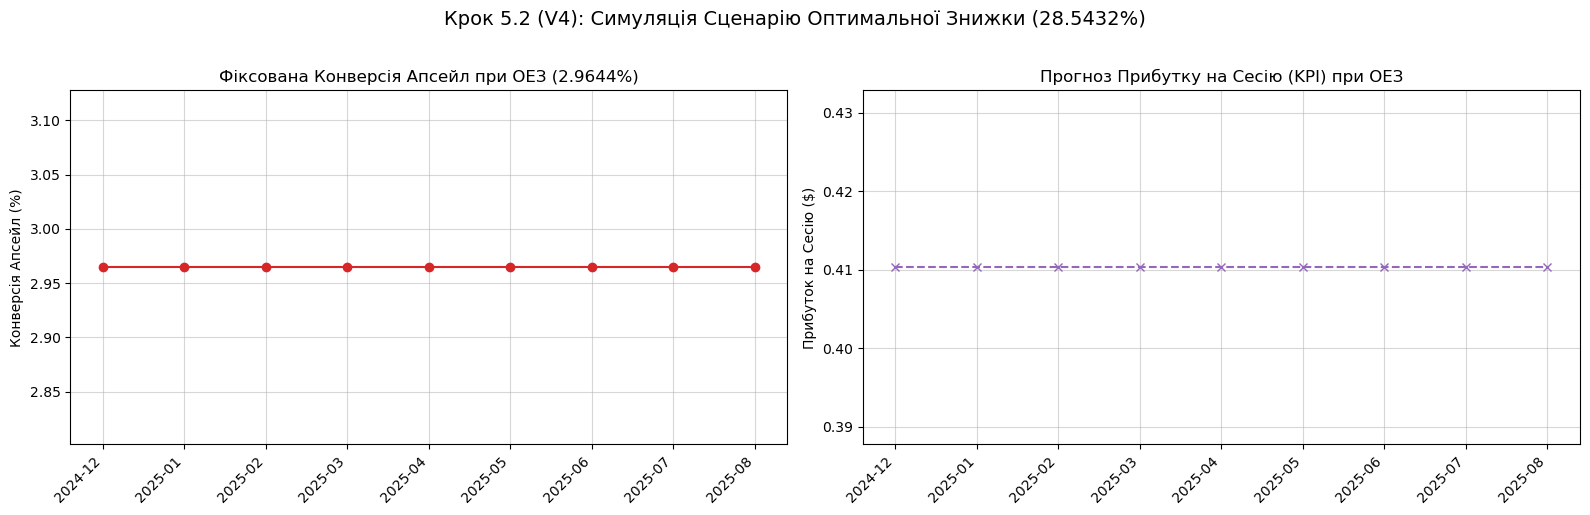

--- КРОК 5.2 (V4): СИМУЛЯЦІЯ З СЕРЕДНЬОЮ ІСТОРИЧНОЮ КОНВЕРСІЄЮ (28.5432% та 2.9644%) ---


date,2024-12-01 00:00:00,2025-01-01 00:00:00,2025-02-01 00:00:00,2025-03-01 00:00:00,2025-04-01 00:00:00,2025-05-01 00:00:00,2025-06-01 00:00:00,2025-07-01 00:00:00,2025-08-01 00:00:00
pack_type,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack,Double Pack
Прогнозована Знижка ОЕЗ (28.5432%),28.5432,28.5432,28.5432,28.5432,28.5432,28.5432,28.5432,28.5432,28.5432
трафік на сінглпак (Total Sessions Single Pack),34727.0000,29451.0000,34926.0000,37693.0000,35434.0000,38376.0000,63594.0000,108390.0000,128509.0000
конверсія апсейл (Upsell Conversion),2.9644,2.9644,2.9644,2.9644,2.9644,2.9644,2.9644,2.9644,2.9644
прибуток на сесію (KPI),0.4103,0.4103,0.4103,0.4103,0.4103,0.4103,0.4103,0.4103,0.4103
чистий прибуток,14248.3434,12083.6226,14329.9922,15465.2808,14538.4225,15745.5129,26092.3532,44471.9653,52726.7071



--- СУМАРНІ ПОКАЗНИКИ ПРОГНОЗУ ОЕЗ ЗІ СЕРЕДНЬОЮ КОНВЕРСІЄЮ ---


,Показник,Значення
0,Сумарний чистий прибуток ($),209702.2000
1,Сумарний трафік (Total Sessions Single Pack),511100


In [31]:
# --- КРОК 5.2 (МОДЕЛЬ V4): СИМУЛЯЦІЯ З СЕРЕДНЬОЮ ІСТОРИЧНОЮ КОНВЕРСІЄЮ ---

# 1. ВИЗНАЧЕННЯ КОНСТАНТ

# Отримуємо числове значення Оптимальної Знижки
optimal_discount = optimal_discount_perc 

# ВИЗНАЧАЄМО НОВУ СТЕЛЮ КОНВЕРСІЇ (СЕРЕДНЄ ІСТОРИЧНЕ)
idx_conversion = 'конверсія апсейл (Upsell Conversion)'
# ОБЧИСЛЮЄМО СЕРЕДНЄ ЗІ СТАРТОВОЇ ТАБЛИЦІ (що дорівнює 3.1400)
HISTORICAL_AVG_CONVERSION = ab_data['baseline_df'].loc[idx_conversion].mean()


# 2. ПІДГОТОВКА ДАНИХ ТА ФІКСАЦІЯ ПАРАМЕТРІВ

# Створюємо копію базової таблиці для симуляції
ab_simulation_df_transposed = ab_data['baseline_df'].copy()

idx_discount = 'історичний відсоток знижки на даблпак (Discount Percentage)'

# ФІКСУЄМО ЗНИЖКУ (ОЕЗ) та КОНВЕРСІЮ (3.14%) для кожного місяця
ab_simulation_df_transposed.loc[idx_discount] = optimal_discount
ab_simulation_df_transposed.loc[idx_conversion] = HISTORICAL_AVG_CONVERSION

# Отримуємо фактичний трафік (залишається незмінним)
sessions = ab_data['full_df']['Total Sessions Single Pack'].values


# 3. ПРЯМИЙ РОЗРАХУНОК: ПРИБУТОК ТА KPI

# ********** РОЗРАХУНОК ПРОГНОЗОВАНОГО ПРИБУТКУ НА ОДИНИЦЮ (Unit Profit) **********
# Прибуток на одиницю не змінюється, оскільки він залежить лише від ОЕЗ (28.54%)

# A. Розрахунок Середньої ціни SP (використовуємо pivoted_data)
sales_sp = pivoted_data.loc['Total Ordered Product Sales'].xs('Single Pack', level='pack_type').sum()
units_sp = pivoted_data.loc['Total Units Ordered'].xs('Single Pack', level='pack_type').sum()
avg_sp_price = sales_sp / units_sp

# B. Розрахунок Прогнозованої Ціни DP при ОЕЗ
price_dp_predicted = (1 - (optimal_discount / 100)) * (2 * avg_sp_price)

# C. Розрахунок Прогнозованого Прибутку на Одиницю (Unit Profit)
ref_fee_dp_predicted = price_dp_predicted * ref_fee_rate
total_cost_predicted = cogs_dp + fba_dp + ref_fee_dp_predicted
profit_per_unit_predicted = price_dp_predicted - total_cost_predicted


# ********** РОЗРАХУНОК ЧИСТОГО ПРИБУТКУ ТА KPI **********

# 1. Розрахунок Прогнозованої КІЛЬКОСТІ ПРОДАЖІВ (Units Ordered)
# Units Ordered = (Conversion / 100) * Sessions
predicted_units_ordered = (HISTORICAL_AVG_CONVERSION / 100) * sessions

# 2. Розрахунок нового Чистого Прибутку
# Total Profit = Units Ordered * Profit per Unit (ОЕЗ)
predicted_total_profit = predicted_units_ordered * profit_per_unit_predicted
ab_simulation_df_transposed.loc['чистий прибуток'] = predicted_total_profit.round(4)

# 3. Розрахунок нового Прибутку на Сесію (KPI)
# KPI = Total Profit / Sessions
predicted_kpi_per_session = predicted_total_profit / sessions
ab_simulation_df_transposed.loc['прибуток на сесію (KPI)'] = predicted_kpi_per_session.round(4)


# --- 4. ВІЗУАЛІЗАЦІЯ ---

dates = ab_simulation_df_transposed.columns.get_level_values(0)
formatted_dates = dates.strftime("%Y-%m") 
kpi_data_sim = ab_simulation_df_transposed.loc['прибуток на сесію (KPI)'].values.astype(float)
conversion_data_sim = ab_simulation_df_transposed.loc[idx_conversion].values.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

# ГРАФІК 1: Фіксована Конверсія Апсейл (3.14%)
ax1 = axes[0]
ax1.plot(conversion_data_sim, color='tab:red', marker='o', linestyle='-')
ax1.set_title(f'Фіксована Конверсія Апсейл при ОЕЗ ({HISTORICAL_AVG_CONVERSION:.4f}%)', fontsize=12)
ax1.set_ylabel('Конверсія Апсейл (%)')
ax1.set_xticks(range(len(dates)))
ax1.set_xticklabels(formatted_dates, rotation=45, ha='right')
ax1.grid(True, alpha=0.5)

# ГРАФІК 2: Прогнозований Прибуток на Сесію (KPI)
ax2 = axes[1]
ax2.plot(kpi_data_sim, color='tab:purple', marker='x', linestyle='--')
ax2.set_title('Прогноз Прибутку на Сесію (KPI) при ОЕЗ', fontsize=12)
ax2.set_ylabel('Прибуток на Сесію ($)')
ax2.set_xticks(range(len(dates)))
ax2.set_xticklabels(formatted_dates, rotation=45, ha='right')
ax2.grid(True, alpha=0.5)

fig.suptitle(f'Крок 5.2 (V4): Симуляція Сценарію Оптимальної Знижки ({optimal_discount:.4f}%)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- 5. ВИВЕДЕННЯ ТА ЗБЕРІГАННЯ ---

print(f"--- КРОК 5.2 (V4): СИМУЛЯЦІЯ З СЕРЕДНЬОЮ ІСТОРИЧНОЮ КОНВЕРСІЄЮ ({optimal_discount:.4f}% та {HISTORICAL_AVG_CONVERSION:.4f}%) ---")

# Створення копії для відображення та перейменування рядка
display_df = ab_simulation_df_transposed.copy()
new_discount_label = f'Прогнозована Знижка ОЕЗ ({optimal_discount:.4f}%)'
display_df = display_df.rename(index={idx_discount: new_discount_label})

# Форматування чисел для відображення: 4 знаки після коми, без роздільників тисяч
display(display_df.style.format('{:.4f}'))


# --- ДОДАТКОВИЙ РОЗРАХУНОК СУМАРНИХ ПОКАЗНИКІВ ---

total_profit_sim = ab_simulation_df_transposed.loc['чистий прибуток'].sum().round(4)
total_sessions_sim = ab_simulation_df_transposed.loc['трафік на сінглпак (Total Sessions Single Pack)'].sum().astype(int)

summary_data_sim = {
    'Показник': ['Сумарний чистий прибуток ($)', 'Сумарний трафік (Total Sessions Single Pack)'],
    'Значення': [f"{total_profit_sim:.4f}", f"{total_sessions_sim}"]
}

summary_df_sim = pd.DataFrame(summary_data_sim)

print("\n--- СУМАРНІ ПОКАЗНИКИ ПРОГНОЗУ ОЕЗ ЗІ СЕРЕДНЬОЮ КОНВЕРСІЄЮ ---")
display(summary_df_sim)


# Зберігаємо симуляційні дані для Кроку 5.3
ab_data['simulation_df'] = ab_simulation_df_transposed
ab_data['optimal_unit_profit'] = profit_per_unit_predicted

<h1 style="color:#0056b3;">ЗВІТ 4: Аналіз Симуляції Змодельованої Знижки</h1>

Цей звіт підсумовує аналіз впливу **Оптимальної Ефективної Знижки ($\text{ОЕЗ} \approx 28.54\%$ )**, порівнюючи Базовий Сценарій з двома реалістичними моделями прогнозів (V3 та V4).

---

## 1. Порівняння Ефективності Сценаріїв

### Базовий Сценарій (Control):
* Середня Конверсія: **3.1400%**
* Сумарний Чистий Прибуток: **252457.79 $**

### Прогноз ОЕЗ (Конверсія 3.14%):
* Використана Конверсія: **3.1400%** (Середня Історична)
* Сумарний Чистий Прибуток: **209702.20 $**
* **Фінансовий Результат:** ВТРАТА **42755.59 $**
* **Зміна Прибутку:** -16.94%

### Прогноз ОЕЗ (Конверсія 2.92%):
* Використана Конверсія: 2.9200% (Консервативна Стеля)
* Сумарний Чистий Прибуток: 206558.24 $
* **Фінансовий Результат:** ВТРАТА 45899.55 $
* **Зміна Прибутку:** -18.18%

---

## 2. Ключові Висновки

### ВПРОВАДЖЕННЯ ОЕЗ НЕ РЕКОМЕНДОВАНО.

**Причина:** Знижка **$\mathbf{28.54\%}$** призводить до такого сильного падіння **Прибутку на одиницю**, що навіть якщо ринок працюватиме на **середньому історичному рівні конверсії ($\mathbf{3.14\%}$)**, вона все одно призведе до прогнозованих **втрат понад $\mathbf{42}$ тисячі доларів**.

---

## 3. Рекомендації щодо Подальших Дій

1.  **Відмова:** Остаточно відкинути знижку **$\mathbf{28.54\%}$**.
2.  **Новий Аналіз:** Необхідно провести аналіз **найкращої історичної знижки**, щоб знайти цінову стратегію, яка фактично збільшувала, а не зменшувала KPI.

---

Тепер ми можемо перейти до аналізу **Найкращої Історичної Знижки**.